
# Séance 6 Août — Classification pratique (Dataset : **Crédit Bancaire**)

- Choisir **quand** et **quel** algorithme de classification utiliser.
- Réaliser tout le **préprocessing** des 4 premières séances avant de modéliser.
- Construire des **pipelines** robustes (imputation, encodage, scaling) et évaluer avec **validation croisée stratifiée**.
- Maîtriser les **métriques** (accuracy, precision, recall, F1, ROC/PR) et le **seuil de décision**.
- Interpréter.


# Importing all the libraries needed

In [2]:
import os
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
from sklearn import preprocessing
import matplotlib
matplotlib.style.use('ggplot')
from sklearn.preprocessing import LabelEncoder

# Context

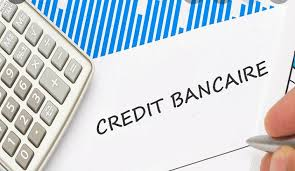


| Variable           | Définition                                                       |
| ------------------ | ---------------------------------------------------------------- |
| Age                | Âge de la personne (en années).                                  |
| Gender             | Genre déclaré de la personne.                                    |
| Income             | Revenu de la personne (montant, idéalement annuel).              |
| Education          | Niveau d’études atteint.                                         |
| Marital Status     | Statut matrimonial (célibataire, marié·e, etc.).                 |
| Number of Children | Nombre d’enfants à charge.                                       |
| Home Ownership     | Statut d’occupation du logement (propriétaire, locataire, etc.). |
| got\_credit        | Cible binaire : vaut 1 si le crédit est accordé, 0 sinon. |


In [1]:
# Télécharger le fichier CSV directement depuis GitHub
!wget https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_6_Classification/Datasets/credit.csv

--2025-08-22 19:23:13--  https://raw.githubusercontent.com/bidoscar/AFRICITIZEN-ACDS-Coding/main/Seance_6_Classification/Datasets/credit.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8251 (8.1K) [text/plain]
Saving to: ‘credit.csv’

credit.csv          100%[===================>]   8.06K  --.-KB/s    in 0s      

2025-08-22 19:23:13 (67.1 MB/s) - ‘credit.csv’ saved [8251/8251]



In [3]:
# Ouvrir les données dans df
df = pd.read_csv("credit.csv")

In [4]:
df.head()

,Age,Gender,Income,Education,Marital_Status,Number_of_Children,Home_Ownership,got_credit
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,1
1,30,Male,100000,Master's Degree,Married,2,Owned,1
2,35,Female,75000,Doctorate,Married,1,Owned,1
3,40,Male,125000,High School Diploma,Single,0,Owned,1
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,1


In [5]:
df.shape

(164, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital_Status      164 non-null    object
 5   Number_of_Children  164 non-null    int64 
 6   Home_Ownership      164 non-null    object
 7   got_credit          164 non-null    int64 
dtypes: int64(4), object(4)
memory usage: 10.4+ KB


# Exploratory Data Analysis

<img src="https://media.giphy.com/media/HUplkVCPY7jTW/giphy.gif">


In [7]:
# vérifions les données manquantes
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Education,0
Marital_Status,0
Number_of_Children,0
Home_Ownership,0
got_credit,0


In [15]:
# Calculons la proportion des doublons
df.duplicated().sum()/df.shape[0]*100

np.float64(37.80487804878049)

In [13]:
# verifier les doublons
# En absence des identifiants
# Supposons que ce ne sont pas les même personnes qui sont répétées

# H1 : Il est peu probable que les même personnes reviennent au point où on ait 338% de doublons
# Donc les doublons identifiés sont en réalité différentes personnes avec les mêmes caratéristiques

# Au final, nous gardons les lignes identifiées comme doublons dans notre jeu de données

In [16]:
#Décrire les données selon le type de data :
  #pour les données quantitatives
df.describe()

,Age,Income,Number_of_Children,got_credit
count,164.000000,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439,0.689024
std,8.477289,32457.306728,0.883346,0.464311
min,25.000000,25000.000000,0.000000,0.000000
25%,30.750000,57500.000000,0.000000,0.000000
50%,37.000000,83750.000000,0.000000,1.000000
75%,45.000000,105000.000000,1.000000,1.000000
max,53.000000,162500.000000,3.000000,1.000000


In [17]:
#Décrire les données selon le type de data :
  #pour les données quantitatives
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,164.0,37.975610,8.477289,25.0,30.75,37.0,45.0,53.0
Income,164.0,83765.243902,32457.306728,25000.0,57500.00,83750.0,105000.0,162500.0
Number_of_Children,164.0,0.652439,0.883346,0.0,0.00,0.0,1.0,3.0
got_credit,164.0,0.689024,0.464311,0.0,0.00,1.0,1.0,1.0


In [20]:
#pour les données catégorielles
df.describe(include='object').T

,count,unique,top,freq
Gender,164,2,Female,86
Education,164,5,Bachelor's Degree,42
Marital_Status,164,2,Married,87
Home_Ownership,164,2,Owned,111


In [ ]:
# Valeurs abérantes

In [21]:
# Selection les colunnes numeriques
num_col=df.select_dtypes(include=np.number).columns
num_col

Index(['Age', 'Income', 'Number_of_Children', 'got_credit'], dtype='object')

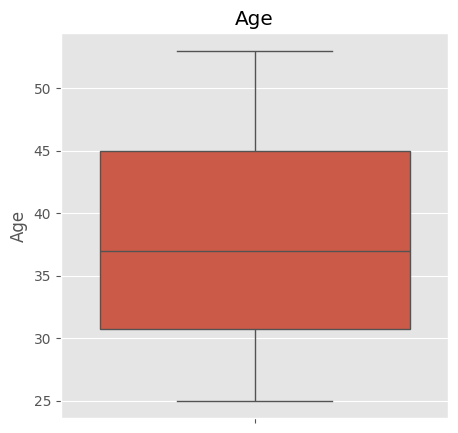

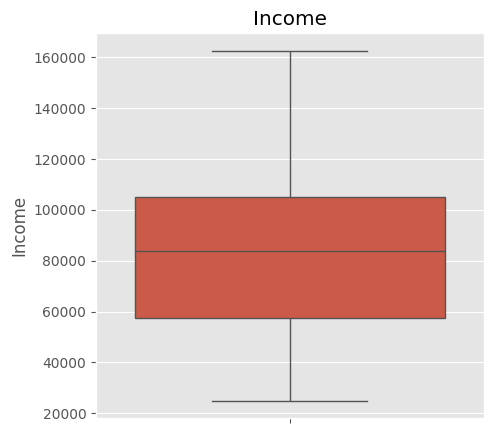

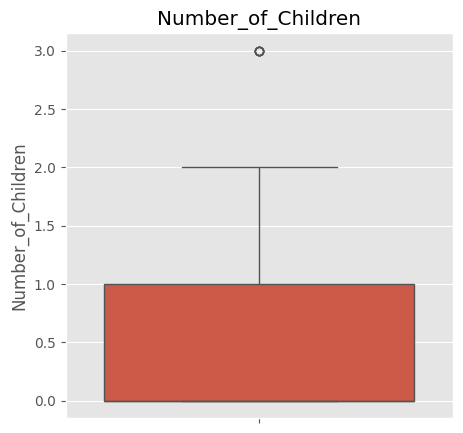

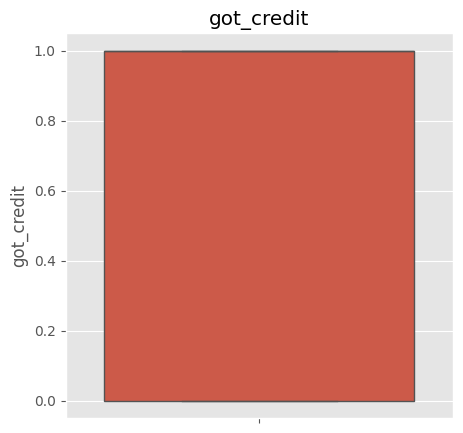

In [22]:
# Pour chaque colunne numérique, faire le boxplot
for col in num_col:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [23]:
df['Number_of_Children'].value_counts()

,count
Number_of_Children,
0,97
1,32
2,30
3,5


In [ ]:
#

# 2. Gestion des variables catégorielles

Les variables catégorielles peuvent être classées en deux grandes catégories :

- **Nominales**  
- **Ordinales**

## 🧠 Quelle méthode utiliser ?

### 🔷 Pour les **modèles non basés sur les arbres** (régression logistique, SVM, KNN, etc.)

➡️ **Utiliser One-Hot Encoding**

- ✅ Avantage : résultat binaire, pas d’ordre artificiel, **vecteurs orthogonaux**.
- ❌ Inconvénient : en cas de **haute cardinalité**, le nombre de colonnes explose → **malédiction de la dimensionnalité**.

📌 **Astuce** : on peut combiner **One-Hot Encoding + PCA** pour réduire la dimension tout en capturant les regroupements de catégories similaires.

---

### 🟩 Pour les **modèles basés sur les arbres** (arbres de décision, forêts aléatoires, etc.)

➡️ **Utiliser Label Encoding**

- Exemple : `['dog', 'cat', 'mouse']` → `[1, 2, 3]`
- ⚠️ Cela introduit un **ordre numérique artificiel**, mais les arbres s’en accommodent bien car ils traitent les variables de manière indépendante.

✅ `LabelEncoder` est aussi **plus léger** (moins de colonnes) et adapté aux arbres de décision.

---

### 📝 Récapitulatif

| Type de modèle                                            | Encodage recommandé   |
|-----------------------------------------------------------|------------------------|
| Modèles **non-arbres** (LogReg, SVM, KNN, etc.)           | ✅ One-Hot Encoding     |
| Modèles **à base d’arbres** (Tree, Random Forest, XGBoost)| ✅ Label Encoding       |


In [ ]:
# Label Ecoding which will be used with Tree Based Algorthms


In [ ]:
## Creaeting one hot encoded features for working with non tree based algorithms


# 3. Feature Scaling


### Pourquoi utiliser la mise à l’échelle des variables ?

La première question à se poser est la suivante : pourquoi devons-nous mettre à l’échelle les variables de notre jeu de données ?  
Certains algorithmes d’apprentissage automatique sont **sensibles** à la mise à l’échelle des caractéristiques, tandis que d’autres y sont quasiment **invariants**. Voici plus de détails.

---

## 1. Algorithmes fondés sur la distance

Les algorithmes de distance comme **KNN**, **K-means** et **SVM** sont les plus affectés par l’échelle des variables.  
En coulisses, ils utilisent des **distances entre points** pour mesurer leur similarité.

Lorsque deux variables n’ont pas la même échelle, il y a un risque que les variables de grande amplitude reçoivent un poids plus élevé.  
Cela peut dégrader les performances de l’algorithme et introduire un **biais** non désiré.

➡️ **On met donc les variables à la même échelle** avant d’utiliser un algorithme basé sur la distance, afin que **chaque variable contribue équitablement** au calcul.


<img src="https://miro.medium.com/max/1000/0*MZKG8sTIdSNv6TXB" width=50%>


## 2. Algorithmes à base d’arbres

Les algorithmes à base d’arbres, en revanche, sont généralement **insensibles à l’échelle** des variables.

Un arbre de décision **scinde un nœud** en fonction d’une seule variable, en choisissant la valeur qui maximise l’homogénéité du sous-groupe.  
Cette décision **ne dépend pas** des autres variables ni de leurs échelles.

✅ C’est pourquoi les arbres (et forêts) ne nécessitent **aucune mise à l’échelle** des variables en entrée.

<img src="https://miro.medium.com/max/925/0*U0rcW7XrdHpvI0hU.jpeg" width=70%>

### Qu’est-ce que la normalisation ?

La **normalisation** est une technique de mise à l’échelle dans laquelle les valeurs sont **décalées et rescalées** pour être comprises entre **0 et 1**.  
On l’appelle aussi **mise à l’échelle Min-Max**.

La formule de la normalisation est la suivante :

<img src="https://i.stack.imgur.com/EuitP.png" width=40%>

> Où `Xmax` et `Xmin` sont respectivement les **valeurs maximale et minimale** de la variable.

---

- Lorsque `X` est égal à **Xmin**, le numérateur vaut 0 → la valeur normalisée **X' = 0**
- Lorsque `X` est égal à **Xmax**, le numérateur = dénominateur → donc **X' = 1**
- Si `X` est **entre** Xmin et Xmax, alors **X' sera compris entre 0 et 1**

✅ La normalisation est **particulièrement utile** lorsque l’on veut que **toutes les variables soient ramenées à une échelle commune**, en particulier pour les algorithmes sensibles aux distances (KNN, SVM, etc.).

## Qu’est-ce que la standardisation ?

La **standardisation** est une autre technique de mise à l’échelle, dans laquelle les valeurs sont **centrées autour de la moyenne** et **réduites à une unité d’écart-type**.  
Cela signifie que la **moyenne devient 0** et que la **distribution résultante a un écart-type égal à 1**.

Voici la formule de la standardisation :

<img src="https://clavelresearch.files.wordpress.com/2019/03/z-score-population.png" width=30%>

---

## La grande question : Normaliser ou Standardiser ?

La question **normalisation vs. standardisation** revient souvent chez les débutants en machine learning. Voici quelques repères pour choisir :

- ✅ **Normalisation** (Min-Max) est préférable **lorsque vos données ne suivent pas une distribution normale**.  
  Elle est utile pour des algorithmes **non paramétriques** comme **K-Nearest Neighbors** ou les **réseaux de neurones**, qui ne font **aucune hypothèse sur la distribution** des données.

- ✅ **Standardisation** est plus adaptée **si les données suivent une distribution gaussienne (normale)**.  
  Mais ce n’est pas une obligation stricte. Contrairement à la normalisation, la standardisation **ne contraint pas les valeurs entre 0 et 1**.  
  Ainsi, les **valeurs extrêmes (outliers)** auront **moins d’impact** après standardisation qu’après normalisation.

---

🎯 **Conclusion** : le choix entre normalisation et standardisation **dépend du problème** et de l’algorithme utilisé.  
Il n’existe **pas de règle absolue**. Il faut tester et évaluer selon le cas.


### Robust Scaler

Lorsqu’on travaille avec des données contenant des **valeurs aberrantes (outliers)**, il est préférable d’utiliser un **scaling robuste** comme `RobustScaler`.

Cette méthode utilise des **statistiques robustes**, c’est-à-dire **moins sensibles aux valeurs extrêmes**.  
Concrètement, elle :

- **soustrait la médiane** de chaque variable  
- puis **divise par l’intervalle interquartile (IQR)**, c’est-à-dire la différence entre le **3ᵉ quartile (Q3)** et le **1er quartile (Q1)**  
  👉 autrement dit, elle **centre les données** et les met à l’échelle dans la plage **[Q1, Q3]**, soit entre le 25ᵉ et le 75ᵉ percentile.

---

✅ L’intérêt majeur du `RobustScaler` est sa **résistance aux valeurs extrêmes**.  
Contrairement à la standardisation (qui dépend de la moyenne et de l’écart-type), ce scaler **n’est pas influencé par quelques valeurs anormalement grandes ou petites**.

📌 Les valeurs de **médiane** et d’**IQR** calculées sont mémorisées pour être **réutilisées** sur de nouvelles données via la méthode `.transform()`.

---

🎯 À retenir :  
Si votre jeu de données contient des **outliers**, `RobustScaler` donne souvent de **meilleurs résultats** que la normalisation (`MinMaxScaler`) ou la standardisation (`StandardScaler`).


# 4 - Choisir la bonne validation croisée

Le choix de la méthode de **validation croisée** dépend du jeu de données utilisé.  
Une technique efficace sur un jeu de données donné **ne sera pas forcément optimale** sur un autre.  
Cependant, il existe des techniques populaires qui sont largement utilisées :

- **k-fold cross-validation**
- **stratified k-fold cross-validation**

La validation croisée consiste à **diviser les données d'entraînement en plusieurs sous-ensembles**.  
On entraîne le modèle sur une partie de ces sous-ensembles et on le teste sur les autres.

<br>

<img src="https://i.stack.imgur.com/8uEci.png" width=50%>

---

## 1. k-fold cross-validation

Comme illustré ci-dessus, les échantillons (et les cibles associées) sont divisés en `k` sous-ensembles **exclusifs**.  
C’est ce qu’on appelle la **validation croisée en k-plis** (*k-fold*).  
Chaque point de donnée est affecté à un des `k` groupes (de 0 à k−1), et chaque pli est utilisé comme ensemble de test une fois.

👉 Vous pouvez facilement implémenter cela avec `KFold` de `scikit-learn`.

---

## 2. Stratified k-fold cross-validation

Si votre jeu de données est **déséquilibré**, par exemple avec **90% de classes positives** et **10% de classes négatives**,  
alors utiliser une k-fold classique de manière aléatoire peut poser problème.

📉 En effet, certaines divisions peuvent contenir uniquement des exemples d’une seule classe, ce qui **fausse les métriques**.

➡️ Dans ce cas, on utilise la **stratified k-fold cross-validation** :  
elle conserve **la proportion de chaque classe constante** dans chaque pli.  
Par exemple, chaque sous-ensemble contiendra **environ 90% de positifs et 10% de négatifs**.

✅ Cela garantit une évaluation **plus stable et représentative**, peu importe la métrique utilisée (AUC, F1, etc.).

---

🎯 **Résumé** :

| Situation                          | Méthode recommandée            |
|-----------------------------------|--------------------------------|
| Données équilibrées               | ✅ k-fold classique             |
| Données déséquilibrées (ex : 90/10) | ✅ stratified k-fold (préserv. des classes) |


# 5 - Modélisation

# NON-TREE BASED ALGORITHMS

<img src="https://media.giphy.com/media/zMukICnMEZmSf8zvXd/giphy.gif">

## 1. Régression logistique

- **Principe** :  
  La régression logistique est un modèle linéaire qui estime la probabilité qu’une observation appartienne à une classe (ex. : 0 ou 1).  
  Elle utilise la **fonction sigmoïde** pour transformer une combinaison linéaire des variables en une probabilité comprise entre 0 et 1.

- **Avantages** :  
  - Facile à comprendre et interpréter (coefficients).  
  - Rapide à entraîner même sur de grands jeux de données.  
  - Probabilités bien calibrées.  

- **Limites** :  
  - Suppose une relation **linéaire** entre les variables et le logit.  
  - Moins performante sur des problèmes **non linéaires** complexes.  

- **Cas d’usage** :  
  - Problèmes de classification binaire (maladie : oui/non, défaut de paiement : oui/non).  
  - Quand l’**interprétabilité** est importante.

  Illustration

<img src="https://datatab.fr/assets/tutorial/linear_regression_equation.png">
Etape 2
<img src="https://datatab.fr/assets/tutorial/Derivation_of_the_Logistic_Regression.png">
Etape 3
<img src="https://datatab.fr/assets/tutorial/Logistic-function.png">

Voici une explication claire et concise de chaque **métrique d’évaluation**, avec leur **interprétation**, **utilité**, et **pièges à éviter** :

---

### ✅ `accuracy_score` → **Exactitude**

```python
acc = accuracy_score(y_valid, y_pred)
```

**Définition** : proportion de bonnes prédictions (positives et négatives) sur l’ensemble des prédictions.

**Formule** :

$$
\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}
$$

* **VP** : vrais positifs
* **VN** : vrais négatifs
* **FP** : faux positifs
* **FN** : faux négatifs

**🧠 Interprétation** : "Mon modèle prédit correctement X% des cas."

**⚠️ Limite** : pas fiable si les classes sont **déséquilibrées**.
Par exemple, avec 90% de classe 0, un modèle qui prédit toujours 0 aura 90% d’accuracy… mais ne détectera **jamais la classe 1**.

---

### ✅ `precision_score` → **Précision**

```python
prec = precision_score(y_valid, y_pred)
```

**Définition** : parmi toutes les **prédictions positives**, quelle proportion est correcte.

**Formule** :

$$
\text{Précision} = \frac{VP}{VP + FP}
$$

**🧠 Interprétation** : "Quand mon modèle dit ‘positif’, il a raison X% du temps."

**📌 Utile quand** les **faux positifs** sont coûteux.
Ex. : un email détecté comme spam alors qu’il ne l’est pas (perte d’un mail important).

---

### ✅ `recall_score` → **Rappel / Sensibilité**

```python
rec = recall_score(y_valid, y_pred)
```

**Définition** : parmi tous les **vrais cas positifs**, combien sont détectés par le modèle.

**Formule** :

$$
\text{Rappel} = \frac{VP}{VP + FN}
$$

**🧠 Interprétation** : "Mon modèle détecte X% des vrais cas positifs."

**📌 Utile quand** les **faux négatifs** sont critiques.
Ex. : ne pas détecter une fraude, une maladie, un défaut.

---

### ✅ `f1_score` → **Score F1**

```python
f1 = f1_score(y_valid, y_pred)
```

**Définition** : moyenne harmonique entre **précision** et **rappel**.

**Formule** :

$$
F1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}
$$

**🧠 Interprétation** : "Combinaison équilibrée entre rappel et précision."

**📌 Utile quand** tu veux un **compromis** entre les deux (ex. : détecter sans trop d’erreurs ni de ratés).

---

### ✅ `roc_auc_score` → **AUC (Area Under the ROC Curve)**

```python
roc_auc = roc_auc_score(y_valid, y_pred)
```

**Définition** : mesure la capacité du modèle à **distinguer les classes**, en tenant compte du **seuil de classification**.

**🧠 Interprétation** :
Probabilité qu’un exemple positif ait une **probabilité prédite plus haute** qu’un exemple négatif.

* 1.0 = parfait
* 0.5 = hasard
* < 0.5 = pire que le hasard (mauvais sens)

**📌 Utile pour** évaluer un modèle indépendamment du seuil (utilisé avec `predict_proba`).

---

### 🎯 En résumé :

| Métrique      | Question posée                                     | À privilégier quand…           |
| ------------- | -------------------------------------------------- | ------------------------------ |
| **Accuracy**  | Globalement, est-ce que mon modèle se trompe peu ? | Données équilibrées            |
| **Précision** | Quand il prédit “positif”, a-t-il raison ?         | Faux positifs coûteux          |
| **Rappel**    | Capte-t-il bien tous les vrais cas ?               | Faux négatifs risqués          |
| **F1-score**  | Fait-il un bon compromis entre les deux ?          | Objectif équilibré             |
| **ROC AUC**   | Distingue-t-il bien les classes en général ?       | Analyse globale de performance |


## 2.Using Naive Bayers

<img src="https://insightimi.files.wordpress.com/2020/04/unnamed-1.png">

2. Naïve Bayes (ex. : `GaussianNB`)

- **Principe** :  
  Basé sur le **théorème de Bayes** :  

  $$
  P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}
  $$

  Il suppose que toutes les variables sont **indépendantes** les unes des autres (hypothèse "naïve").  
  - `GaussianNB` : suppose que les variables suivent une loi normale (gaussienne).

- **Avantages** :  
  - Très rapide à entraîner et prédire.  
  - Fonctionne bien même avec peu de données.  
  - Gère naturellement les données textuelles (via fréquences).  

- **Limites** :  
  - L’hypothèse d’indépendance est souvent **fausse**.  
  - Performances limitées sur des données fortement corrélées.  

- **Cas d’usage** :  
  - Filtrage d’emails (spam vs non spam).  
  - Classification de texte, NLP.  

## 3.Using SVM(Support Vector Machines):

3. SVM — Support Vector Machines (avec différents noyaux)

- **Principe** :  
  Le SVM cherche à **séparer les classes** en trouvant un **hyperplan** qui maximise la **marge** (distance entre les classes et l’hyperplan).  

  - **Kernel linéaire** : sépare les classes avec une droite (2D) ou un plan (3D).  
  - **Kernel polynomial / RBF (Radial Basis Function)** : permet de séparer des classes **non linéaires** en projetant les données dans un espace de dimension supérieure.  

- **Avantages** :  
  - Très efficace sur des données complexes.  
  - Fonctionne bien avec peu d’exemples mais de nombreuses variables.  
  - Flexible grâce aux différents noyaux (kernel).  

- **Limites** :  
  - Peut être lent sur de très grands jeux de données.  
  - Les paramètres (C, gamma, degré) nécessitent du tuning.  
  - Moins interprétable.  

- **Cas d’usage** :  
  - Reconnaissance d’images (visages, chiffres manuscrits).  
  - Données complexes où les classes ne sont pas séparables linéairement.  

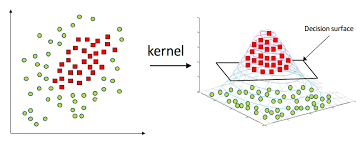

## Using K-nearest Neighbors
T4. k-Nearest Neighbors (k-NN)

- **Principe** :  
  Non paramétrique, simple :  
  - Pour une nouvelle observation, on regarde les **k voisins les plus proches** dans l’espace des données.  
  - La classe majoritaire de ces voisins est attribuée à l’observation.  

- **Avantages** :  
  - Facile à comprendre et implémenter.  
  - Pas d’entraînement complexe (lazy learner).  
  - S’adapte aux données non linéaires.  

- **Limites** :  
  - Coût élevé en prédiction (doit comparer avec tous les points).  
  - Sensible au **choix de k** et à la **mise à l’échelle** des variables.  
  - Performances faibles si beaucoup de variables (**malédiction de la dimensionnalité**).  

- **Cas d’usage** :  
  - Recommandation (utilisateurs similaires).  
  - Problèmes où la proximité entre points est significative.
  
<img src="http://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1531424125/KNN_final1_ibdm8a.png">
